In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('../')

import superstats as sup

## Specify Joint Prior

In [4]:
prior = sup.prior.JointPrior(
    v = sup.transition.JumpTransition(
        sup.transition.RandomWalk(
            bounds=(0.0, 6.0),
            sigma=sup.prior.Prior(dist="halfnormal", scale=0.15),
        ),
        jump_prob=0.05,
    ),
    a = sup.transition.RandomWalk(
        bounds=(0.0, 6.0),
        sigma=sup.prior.Prior(dist="halfnormal", scale=0.15),
        delta=0.0
    ),
    bias = 0.5,
    tau = sup.transition.RandomWalk(
        bounds=(0.0, 6.0),
        sigma=sup.prior.Prior(dist="halfnormal", scale=0.15),
        delta=0.0
    ),
)

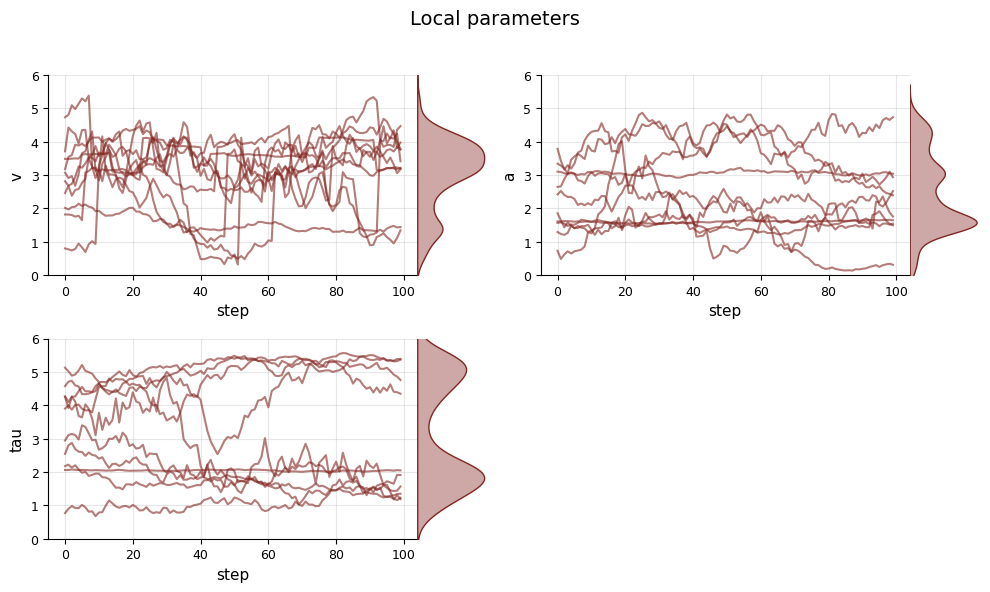

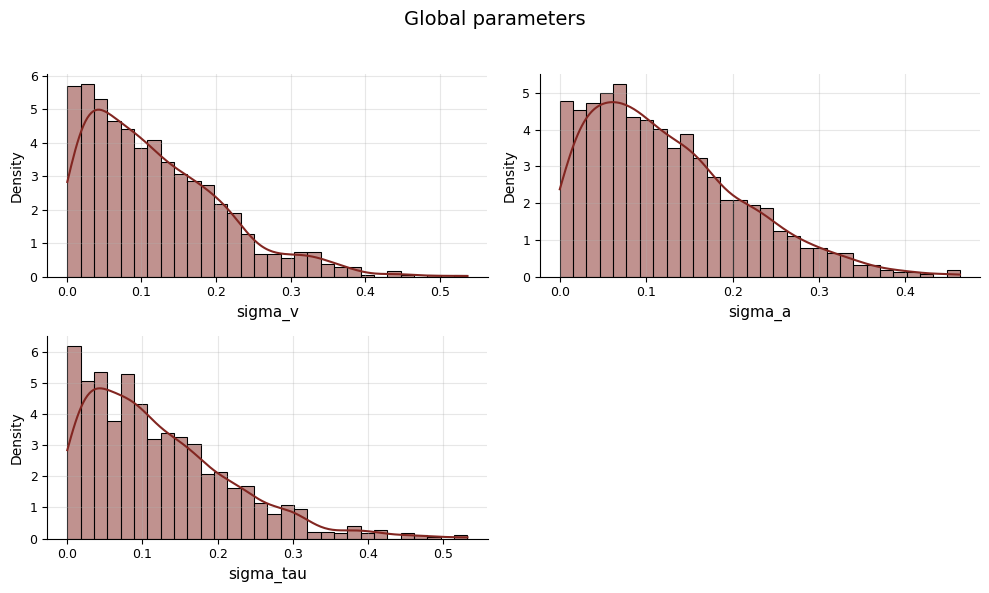

In [58]:
prior.plot_prior(num_trajectories=10)

## Specify Generative Model

In [43]:
cognitive_model = sup.simulation.sample_ddm

In [44]:
generative_model = sup.simulation.GenerativeModel(
    prior=prior,
    model=cognitive_model,
)

In [45]:
%%timeit
sim_data = generative_model.sample(batch_size=32, steps=500)

22 ms ± 3.18 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [46]:
sim_data = generative_model.sample(batch_size=32, steps=500)
sim_data.keys()

dict_keys(['data', 'local_params', 'global_params', 'shared_params', 'infer_mask'])